# Mistral-7B-Instruct

In [1]:
# Install dependencies
!pip install transformers datasets peft accelerate scikit-learn matplotlib seaborn bitsandbytes -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.8 MB/s eta 0:00:00


In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

# ── Configuration (Optimized for Memory) ──────────────────────────────────
MODEL_ID    = "infly/OpenCoder-1.5B-Base"
HF_TOKEN    = ""
MAX_LEN     = 512
TRAIN_SEED  = 42
TRAIN_SIZE  = 4000
VALID_SIZE  = 1000
BATCH_SIZE  = 8
GRAD_ACC    = 4
LR          = 2e-4
EPOCHS      = 3
LORA_R      = 16
LORA_ALPHA  = 32
LORA_DROP   = 0.1
NUM_LABELS  = 2
OUTPUT_DIR  = f"./results-OpenCoder-1.5B-Base"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"Model  : {MODEL_ID}")

Device : cuda
Model  : infly/OpenCoder-1.5B-Base


In [3]:
# Log in to HuggingFace (required for gated models)
from huggingface_hub import login
if HF_TOKEN:
    login(token=HF_TOKEN)
else:
    print("WARNING: HF_TOKEN not set. Gated models will fail to load.")


In [4]:
# Load and subsample dataset
dataset = load_dataset("google/code_x_glue_cc_defect_detection")

train_full = dataset["train"].shuffle(seed=TRAIN_SEED)
valid_full = dataset["validation"].shuffle(seed=TRAIN_SEED)
test_split = dataset["test"]

train_sub = train_full.select(range(min(TRAIN_SIZE, len(train_full))))
valid_sub = valid_full.select(range(min(VALID_SIZE, len(valid_full))))

print(f"Train subset : {len(train_sub):,}")
print(f"Valid subset : {len(valid_sub):,}")
print(f"Test split   : {len(test_split):,}")

# Label check
import collections
print("Train label dist:", collections.Counter(train_sub["target"]))


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/2.21M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/21854 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2732 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2732 [00:00<?, ? examples/s]

Train subset : 4,000
Valid subset : 1,000
Test split   : 2,732
Train label dist: Counter({False: 2166, True: 1834})


In [5]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    token=HF_TOKEN if HF_TOKEN else None,
    trust_remote_code=True,
)

# Decoder-only models often lack a pad token.
# We reuse eos_token as pad_token, which is standard practice.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# CRITICAL for decoder-only models used in classification:
# These models take the hidden state of the LAST token as the classifier input.
# With right padding (default), the last token is PAD -> classifier sees garbage.
# With left padding, the last token is always the final real code token -> correct.
tokenizer.padding_side = "left"

# Save the original bos_token_id before model loading so we can
# restore it later if HuggingFace token alignment sets it to None.
ORIGINAL_BOS_ID = tokenizer.bos_token_id

print("Vocab size    :", tokenizer.vocab_size)
print("Pad token     :", tokenizer.pad_token)
print("Padding side  :", tokenizer.padding_side)
print("BOS token id  :", ORIGINAL_BOS_ID)


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenization_inflm.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/infly/OpenCoder-1.5B-Base:
- tokenization_inflm.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer.model:   0%|          | 0.00/1.54M [00:00<?, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

Vocab size    : 96499
Pad token     : <pad>
Padding side  : left
BOS token id  : 1


In [6]:
from datasets import Value
# Tokenize datasets
def tokenize(batch):
    return tokenizer(
        batch["func"],
        truncation=True,
        max_length=MAX_LEN,
        padding=False,      # DataCollatorWithPadding handles dynamic padding
    )

# Remove text/meta columns only. "target" (label) is preserved here,
# then renamed to "labels" below as required by HuggingFace Trainer.
cols_to_remove = ["func", "project", "commit_id"]

train_tok = train_sub.map(tokenize, batched=True, remove_columns=cols_to_remove)
valid_tok = valid_sub.map(tokenize, batched=True, remove_columns=cols_to_remove)
test_tok  = test_split.map(tokenize, batched=True, remove_columns=cols_to_remove)

# Rename "target" -> "labels"
train_tok = train_tok.rename_column("target", "labels")
valid_tok = valid_tok.rename_column("target", "labels")
test_tok  = test_tok.rename_column("target", "labels")

# cast labels
train_tok = train_tok.cast_column("labels", Value("int64"))
valid_tok = valid_tok.cast_column("labels", Value("int64"))
test_tok  = test_tok.cast_column("labels", Value("int64"))

# remove id column if exists
if "id" in train_tok.column_names:
    train_tok = train_tok.remove_columns(["id"])
    valid_tok = valid_tok.remove_columns(["id"])
    test_tok  = test_tok.remove_columns(["id"])

train_tok.set_format("torch")
valid_tok.set_format("torch")
test_tok.set_format("torch")

print("Tokenization complete.")
print("Train features:", train_tok.features)


Parameter 'function'=<function tokenize at 0x7bf7721602c0> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2732 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2732 [00:00<?, ? examples/s]

Tokenization complete.
Train features: {'labels': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


In [7]:
# Load base model with classification head
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=NUM_LABELS,
    quantization_config=bnb_config,
    token=HF_TOKEN if HF_TOKEN else None,
    trust_remote_code=True,
    dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map="auto" if DEVICE == "cuda" else None,
    ignore_mismatched_sizes=True,
)

# Align pad_token_id explicitly so HuggingFace does not auto-sync
# all special tokens (which can set bos_token_id to None).
model.config.pad_token_id = tokenizer.pad_token_id

# Restore bos_token_id if it was overwritten to None during from_pretrained
# token alignment. This suppresses the PAD/BOS/EOS mismatch warning.
if model.config.bos_token_id is None and ORIGINAL_BOS_ID is not None:
    model.config.bos_token_id = ORIGINAL_BOS_ID

# Explicitly declare this is a single-label classification task.
# Without this, the Trainer may infer the wrong loss function
# (e.g. BCEWithLogitsLoss instead of CrossEntropyLoss), causing nan loss.
model.config.problem_type = "single_label_classification"

# Apply LoRA (PEFT)
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROP,
    bias="none",
    # Target standard attention projection layers
    target_modules=["q_proj", "v_proj"],
)

model = get_peft_model(model, lora_config)

# LoRA adapters inherit the base model dtype (float16).
# PyTorch grad scaler cannot unscale fp16 gradients, so trainable
# parameters must be explicitly upcast to float32 before training.
for name, param in model.named_parameters():
    if param.requires_grad:
        param.data = param.data.to(torch.float32)

model.print_trainable_parameters()


model.safetensors:   0%|          | 0.00/3.81G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: infly/OpenCoder-1.5B-Base
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 3,445,120 || all params: 1,692,626,880 || trainable%: 0.2035


In [8]:
# Compute metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall":    recall_score(labels, preds, zero_division=0),
        "f1":        f1_score(labels, preds, zero_division=0)
    }


In [9]:
# Training arguments
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACC,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_steps=200,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=True,                   # Bật fp16 để tính toán nhanh và tiết kiệm mem
    logging_steps=10,
    report_to="none",
    dataloader_num_workers=2,
    seed=TRAIN_SEED,
    gradient_checkpointing=True, # Kỹ thuật quan trọng để tránh OOM
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

from torch.nn import CrossEntropyLoss

label_counts = np.bincount(train_tok["labels"])
total = label_counts.sum()
class_weights = torch.tensor(
    [total / (2 * c) for c in label_counts],
    dtype=torch.float32
).to(DEVICE)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = CrossEntropyLoss(weight=class_weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=valid_tok,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Trainer initialized with memory optimizations.")

Trainer initialized with memory optimizations.


In [10]:
# Train the model
train_result = trainer.train()
print("Training complete.")
print(f"Training loss     : {train_result.training_loss:.4f}")
print(f"Training runtime  : {train_result.metrics['train_runtime']:.1f}s")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.930237,0.736359,0.532000,0.484956,0.607539,0.539370
2,2.722212,0.723862,0.592000,0.598174,0.290466,0.391045
3,1.925647,0.688008,0.615000,0.580488,0.527716,0.552846


Training complete.
Training loss     : 2.7983
Training runtime  : 4680.9s


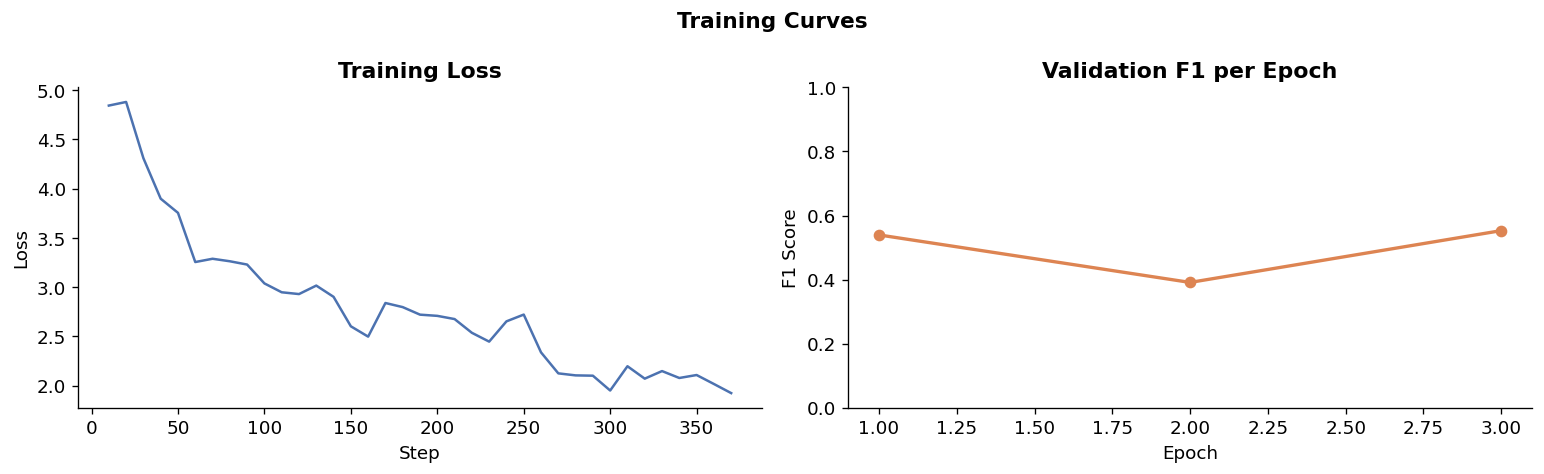

In [11]:
# Plot training loss curve
log_history = trainer.state.log_history
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_loss" in x]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if train_logs:
    steps = [x["step"] for x in train_logs]
    losses = [x["loss"] for x in train_logs]
    axes[0].plot(steps, losses, color="#4C72B0", linewidth=1.5)
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training Loss", fontweight="bold")
    axes[0].spines[["top", "right"]].set_visible(False)

if eval_logs:
    epochs_e = [x["epoch"] for x in eval_logs]
    f1_scores = [x.get("eval_f1", 0) for x in eval_logs]
    axes[1].plot(epochs_e, f1_scores, marker="o", color="#DD8452", linewidth=2)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1 Score")
    axes[1].set_title("Validation F1 per Epoch", fontweight="bold")
    axes[1].spines[["top", "right"]].set_visible(False)
    axes[1].set_ylim(0, 1)

plt.suptitle(f"Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("training_curves.png", bbox_inches="tight")
plt.show()


In [12]:
# Evaluate on test set
test_output = trainer.predict(test_tok)
logits = test_output.predictions
labels = test_output.label_ids
probs  = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
preds  = np.argmax(logits, axis=-1)

acc = accuracy_score(labels, preds)
pre = precision_score(labels, preds, zero_division=0)
rec = recall_score(labels, preds, zero_division=0)
f1  = f1_score(labels, preds, zero_division=0)
fpr, tpr, _ = roc_curve(labels, probs)
roc_auc = auc(fpr, tpr)

print("=== Test Set Evaluation ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {pre:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC       : {roc_auc:.4f}")
print()
print(classification_report(labels, preds, target_names=["Clean", "Defective"]))


=== Test Set Evaluation ===
Accuracy  : 0.6007
Precision : 0.5707
Recall    : 0.5275
F1 Score  : 0.5482
AUC       : 0.6314

              precision    recall  f1-score   support

       Clean       0.62      0.66      0.64      1477
   Defective       0.57      0.53      0.55      1255

    accuracy                           0.60      2732
   macro avg       0.60      0.60      0.60      2732
weighted avg       0.60      0.60      0.60      2732



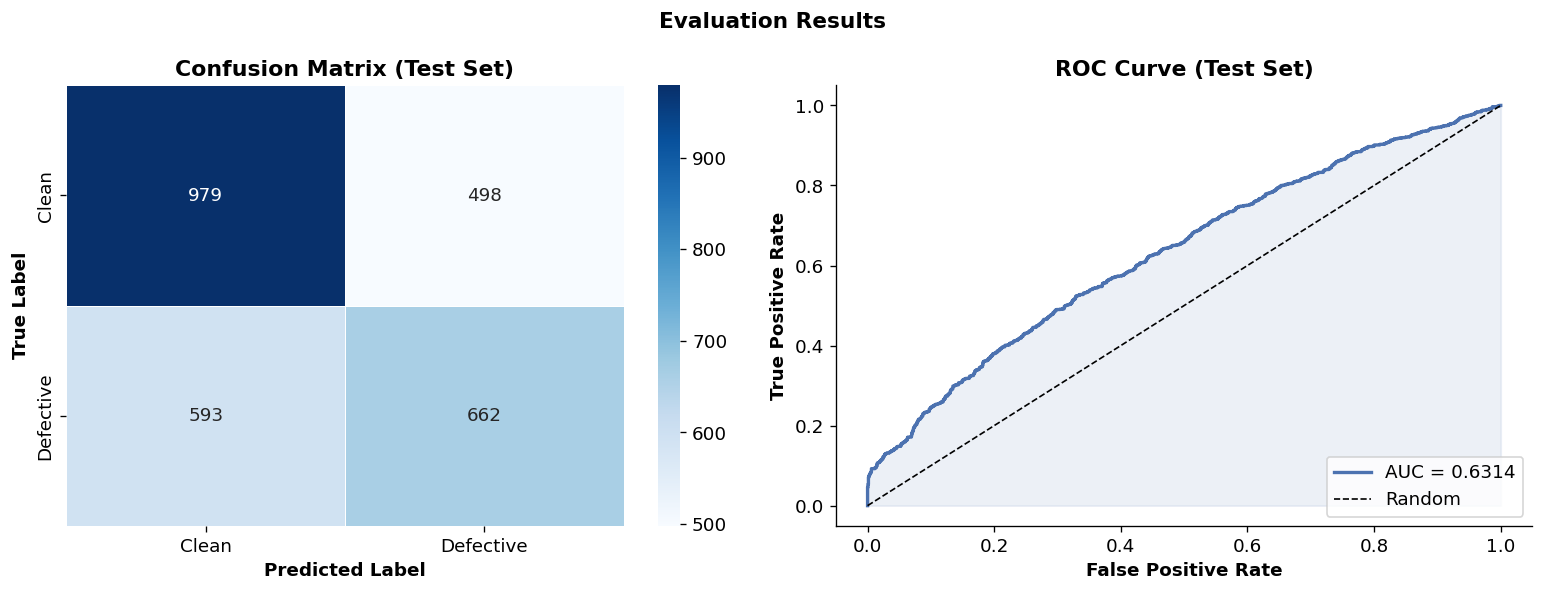

In [13]:
# Visualization: Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Clean", "Defective"],
            yticklabels=["Clean", "Defective"],
            ax=axes[0], linewidths=0.5)
axes[0].set_xlabel("Predicted Label", fontweight="bold")
axes[0].set_ylabel("True Label", fontweight="bold")
axes[0].set_title("Confusion Matrix (Test Set)", fontweight="bold")

# ROC Curve
axes[1].plot(fpr, tpr, color="#4C72B0", linewidth=2,
             label=f"AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#4C72B0")
axes[1].set_xlabel("False Positive Rate", fontweight="bold")
axes[1].set_ylabel("True Positive Rate", fontweight="bold")
axes[1].set_title("ROC Curve (Test Set)", fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Evaluation Results", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("evaluation_results.png", bbox_inches="tight")
plt.show()


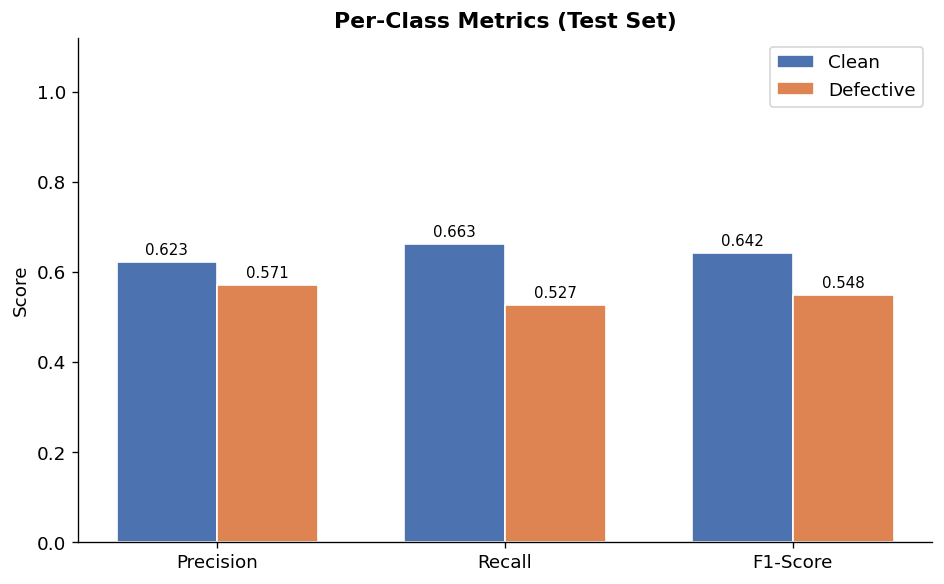

In [14]:
# Per-class metrics bar chart
class_report = classification_report(
    labels, preds,
    target_names=["Clean", "Defective"],
    output_dict=True
)

metrics = ["precision", "recall", "f1-score"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2,
               [class_report["Clean"][m] for m in metrics],
               width, label="Clean", color="#4C72B0", edgecolor="white")
bars2 = ax.bar(x + width/2,
               [class_report["Defective"][m] for m in metrics],
               width, label="Defective", color="#DD8452", edgecolor="white")

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(["Precision", "Recall", "F1-Score"])
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Per-Class Metrics (Test Set)", fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("per_class_metrics.png", bbox_inches="tight")
plt.show()


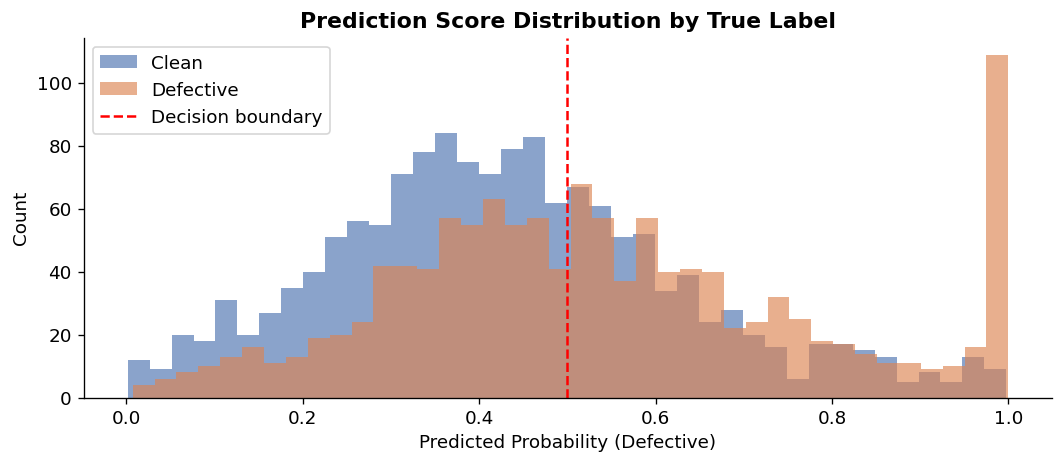

In [15]:
# Score distribution by true label
fig, ax = plt.subplots(figsize=(9, 4))
for label_val, color, name in zip([0, 1], ["#4C72B0", "#DD8452"], ["Clean", "Defective"]):
    subset_probs = probs[labels == label_val]
    ax.hist(subset_probs, bins=40, alpha=0.65, color=color,
            label=name, edgecolor="none")
ax.axvline(0.5, color="red", linestyle="--", linewidth=1.5, label="Decision boundary")
ax.set_xlabel("Predicted Probability (Defective)")
ax.set_ylabel("Count")
ax.set_title("Prediction Score Distribution by True Label", fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("score_distribution.png", bbox_inches="tight")
plt.show()


In [16]:
# Final results summary
print("=== Final Results Summary ===")
results_df = pd.DataFrame([{
    "Model": MODEL_ID,
    "Accuracy":  round(acc, 4),
    "Precision": round(pre, 4),
    "Recall":    round(rec, 4),
    "F1":        round(f1, 4),
    "AUC":       round(roc_auc, 4),
}])
print(results_df.to_string(index=False))


=== Final Results Summary ===
                    Model  Accuracy  Precision  Recall     F1    AUC
infly/OpenCoder-1.5B-Base    0.6007     0.5707  0.5275 0.5482 0.6314


In [17]:
# Save the fine-tuned model
model.save_pretrained(OUTPUT_DIR + "/best_model")
tokenizer.save_pretrained(OUTPUT_DIR + "/best_model")
print(f"Model saved to: {OUTPUT_DIR}/best_model")


Model saved to: ./results-OpenCoder-1.5B-Base/best_model
